Created by Angelo Orletti Del Rey for its masters in psychiatry at Unifesp - SP - Brasil

It was based in our groups previeous works in cotical striatal connectivity in INPD data base of fmri

In [1]:
import numpy as np
import os, sys
import bids
import nibabel as nib
from scipy.stats import chi2
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import matplotlib.pyplot as plt

import argparse
import pandas as pd

from sklearn.preprocessing import StandardScaler

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Suppress convergence warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")


In [2]:
def parse():

        options = argparse.ArgumentParser(description="Run 1st level analysis. Created by ...")
        options.add_argument('-p', '--participants', nargs='+',dest="participants", action='store', type=str, required=False,
                            help='id of subject or list of subjects')
        options.set_defaults(participants=None)
        options.add_argument('-w', '--workdir',dest="workdir", action='store', type=str, required=False,
                            help='the work directory for the project')
        options.set_defaults(workdir=os.environ["ROOTDIR"])
        options.add_argument('-b', '--bidsdir',dest="rawdata", action='store', type=str, required=False,
                            help='the work directory for the project')
        options.set_defaults(rawdata=os.path.join(os.environ["ROOTDIR"],"BIDS"))
        options.add_argument('-d', '--derivatives',dest="derivatives", action='store', type=str, required=True,
                            help='path to fMRIprep directory')
        options.add_argument('-o', '--outputs',dest="output", action='store', type=str, required=True,
                            help='path to fMRIprep directory')
        #print(options.parse_args())

        return options.parse_args()

os.environ["ROOTDIR"] = r'D://'   # seth path
rootdir = os.environ["ROOTDIR"]
if hasattr(sys, "ps1"):
    options = {}
    workdir = os.environ["ROOTDIR"]
    firstleveldir  = os.path.join(workdir,"BIDS","derivatives","first_level_results")
    demographic = os.path.join(workdir,"metadata")
    confounds = os.path.join(workdir,"metadata")
    output = os.path.join(workdir,'second_level_results')
    participants = []

else :
    options = parse()
    participants = options.participants
    workdir = options.workdir
    rawdata = options.rawdata
    derivat = options.derivatives
    output  = options.outputs

print('firstlevel: ', firstleveldir)
    
bidslayout = bids.BIDSLayout(firstleveldir, validate = False) #With validate = True it doesn't find any subjects

if not participants:
    participants = bidslayout.get_subjects() #take all subjects
    #participants_sub = ["sub-" + item for item in participants]

seednames = ['DCPutamen',
            'DorsalCaudate',
            'DRPutamen',
            'InfVentralCaudate',
            'SupVentralCaudate',
            'VRPutamen'
            ]

tmap_allsubj = [] #initialize array for tmaps

print("Loading tmaps for all participants...")
for p in participants:
    #print(f"Subject: {p}")
    p = p.replace("sub-", "")

    # for ses in bidslayout.get_sessions(subject=p):
    #     #print(f"Session: {ses}")                
    
    ses = '1'

    for r in bidslayout.get_runs(subject=p, session=ses):
        #print(f"Run: {r}")

        tmap_metadata = {
            'task': 'rest',
            'suffix': 'tstat',
            'extension': '.txt',
            'run': str(r),
            'session': str(ses),
            'subject': 'sub-'+p,
            'space': 'MNI152NLin2009cAsym',
            'seed': 'SeedtoROI'
        }

        # Save each tmap as a nifti file
        filepath = os.path.join(firstleveldir,tmap_metadata["subject"],"ses-"+tmap_metadata['session'],"func")
        filename = tmap_metadata["subject"] + "_" + \
                    "ses-"+tmap_metadata['session'] + "_" + \
                    "task-"+tmap_metadata['task'] + "_" + \
                    "run-"+tmap_metadata['run'] + "_" + \
                    "space-"+tmap_metadata['space'] + "_" + \
                    "seed-"+tmap_metadata['seed'] + "_" + \
                    tmap_metadata["suffix"] + \
                    tmap_metadata["extension"]
        tmap_path = os.path.join(filepath, filename)

        #load the tmaps for each subject and then append to the tmap_allsubj array
        tmap = pd.read_csv(tmap_path, delimiter=' ', header=None, skiprows=1) #also skips the first row
        tmap.columns = seednames
        tmap_allsubj.append(tmap)

#load socioeconomic and psichometric data for all subjects
print("Loading socioeconomic and psichometric data for all participants...")
socio_psi=pd.read_csv(os.path.join(demographic,'variaveis_analise_conf_nova-exclusão.tsv'), sep='\t')
#substitute in age colunm , to . for decimals if necessary and convert to float
# socio_psi['age'] = socio_psi['age'].str.replace(',', '.').astype(float)

# organinzing the tmaps. Joining the columns of the tmaps for all subjects. So for each subject
# we have to join the first collunm of the first tmap with the first column of the second tmap and so on
# and then join the second column of the first tmap with the second column of the second tmap and so on
# and so on
print("Organizing tmaps...")
tmap_allsubj = pd.concat(tmap_allsubj, axis=1)
tmap_allsubj_organized = {}

for seed in seednames:
    #drop columns with names different from seednames[i]
    tmap_allsubj_organized[seed] = tmap_allsubj.drop(columns=[col for col in tmap_allsubj.columns if col != seed])

# What do we have now: tmap_allsubj_organized is a dictionary with keys being the seednames and values being
# dataframes with the tmaps for all subjects for that seed. This have dimensions of n_ROIs x n_subjects
# Now we have to transpose it to get the data in the format n_subjects x n_ROIs and then join with the
# socioeconomic and psichometric data
# Also, we have to add the sub_id column to the conectivity data to be able to join with the socioeconomic
# and psichometric data
subs = {'sub_id': []}
for p in participants:
    ses = '1'
    if bidslayout.get_runs(subject=p, session=ses) != []:
        subs['sub_id'].append('sub-'+p)

subs = pd.DataFrame(subs)

# create the collunms names for the data frame of rois
roi_names = [f'roi_{i}' for i in range(101)]

for seed in seednames:
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].transpose()
    tmap_allsubj_organized[seed].columns = roi_names
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].reset_index().join(subs, how='inner')
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].drop(columns=['index'])

# Now we have to join the tmaps with the socioeconomic and psichometric data
print("Joining tmaps with socioeconomic and psichometric data...")

for seed in seednames:
    tmap_allsubj_organized[seed] = pd.merge(tmap_allsubj_organized[seed], socio_psi, on='sub_id', how='inner')
    # scaling the data for the regression for the continous variables age, abepscore, cape
    # and for the rois
    # Scale all ROIs
    roi_cols = [f'roi_{i}' for i in range(101)]
    scaler_roi = StandardScaler()
    tmap_allsubj_organized[seed][roi_cols] = scaler_roi.fit_transform(tmap_allsubj_organized[seed][roi_cols])
    
    # Scale age and abepscore together
    scaler_demo = StandardScaler()
    tmap_allsubj_organized[seed][['age', 'abepscore']] = scaler_demo.fit_transform(tmap_allsubj_organized[seed][['age', 'abepscore']])
    


firstlevel:  D://BIDS\derivatives\first_level_results
Loading tmaps for all participants...
Loading socioeconomic and psichometric data for all participants...
Organizing tmaps...
Joining tmaps with socioeconomic and psichometric data...


# Running linear models
CAPE ~ FuncConn + age  + sex  + socioeconomic + meanFD + FamilyHistory + Site

In [3]:
# now we run the regression analysis for each seed. The dependent variable is the connectivity and the independent
# variables are the CAPE scores. The socioeconomic variables are used as confound variables
print("Running regression analysis (salience, CENTRAL EXECUTIVE and default mode network)...")

shaeffer_network = pd.read_csv(os.path.join(demographic, 
    'tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-100Parcels7Networks_dseg.tsv'), delimiter='\t')

# selecting only the rois that belong to the salience network (name with SalVentAttn) 
# or the default mode network (name with Default)
shaeffer_network = shaeffer_network[shaeffer_network['name'].str.contains('SalVentAttn|Default|Cont')]
print("Selected ROIs for analysis:", shaeffer_network['index'].tolist())
print("There are", len(shaeffer_network['index'].tolist()), "rois in the salience, CENTRAL EXECUTIVE and default mode network that will be analyzed")

# running the regression analysis for each roi in the salience network
results_networks = {} 
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    results_networks[cape] = {}
    for seed in seednames:
        results_networks[cape][seed] = {}
        #salience analisys
        for roi in shaeffer_network['index']:

            
            #running the regression analysis
            # With colection_site and selection as a random effect
            model = smf.ols(f'{cape} ~ roi_{roi} + age  + C(gender)  + abepscore + fd_mean_value + C(selection) + C(colection_site)', 
                                data=tmap_allsubj_organized[seed])
            fit = model.fit()

            # Extract desired values
            results_networks[cape][seed][roi] = {
                'coef': fit.params[f'roi_{roi}'],
                'intercept': fit.params['Intercept'],
                't_value': fit.tvalues[f'roi_{roi}'],
                'p_value': fit.pvalues[f'roi_{roi}'],
                # 't-value_selection': fit.tvalues['selection'],
                # 'p-value_selection': fit.pvalues['selection'],
                'AIC': fit.aic,
                'BIC': fit.bic,
                # 'deviance': fit.deviance,
                # 'R_squared_ajusted': fit.rsquared_adj,
                # 'degrees_of_freedom': fit._iweights.sum() - len(fit.params),
                'residuals': fit.resid,
                # 'mcFadden_R_squared': 1 - fit.deviance / fit.null_deviance,
                'log_likelihood': fit.llf
            }
            
# correcting the p-values in two types: 
# first corret to all p-values in each CAPE score (corr_p_val_within_cape).
# second correct to all p-values in the comparison (corr_p_val_general).

from statsmodels.stats.multitest import multipletests
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    print(f'Intra CAPE FDR - {cape}')
    
    pvals = []
    keys = []  # <- guardar correspondência
    
    # coletar p-values + chaves
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            pvals.append(results_networks[cape][seed][roi]['p_value'])
            keys.append((seed, roi))
    
    print(f'Number of p-values to correct for {cape}: {len(pvals)}')

    # correção FDR
    corrected = multipletests(pvals, method='fdr_bh')[1]

    # reatribuir corretamente
    for (seed, roi), corr_p in zip(keys, corrected):
        results_networks[cape][seed][roi]['corr_p_value_within_cape'] = corr_p

        if corr_p <= 0.05:
            print(f"###{cape} seed-{seed} roi-{roi} -> corr_p_val_within_cape {corr_p:.3f} -> Association {results_networks[cape][seed][roi]['coef']:.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} ")#-> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f}")

        if corr_p <= 0.10:
            print(f">>>{cape} seed-{seed} roi-{roi} -> corr_p_val_within_cape {corr_p:.3f} -> Association {results_networks[cape][seed][roi]['coef']:.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} ")#-> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f}")


print('No FDR Corretion')
# printing the ones that are significant without correcting for all CAPE scores together
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            if results_networks[cape][seed][roi]['p_value'] <= 0.005:
                print(f"### {cape} roi-{roi} -> p_val {results_networks[cape][seed][roi]['p_value']:.3f} -> Association {(results_networks[cape][seed][roi]['coef']):.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} ")#-> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f} ")

#printing the top five highest associations for each CAPE score without correcting for all CAPE scores together
print('---Top 5 associations for each CAPE score without general FDR correction---')
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    associations = []
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            associations.append((results_networks[cape][seed][roi]['coef'], cape, seed, roi, results_networks[cape][seed][roi]['p_value'], results_networks[cape][seed][roi]['t_value'], results_networks[cape][seed][roi]['corr_p_value_within_cape']))
    # Sort the associations by absolute value of the coefficient and get the top 5
    top_associations = sorted(associations, key=lambda x: abs(x[0]), reverse=True)[:5]
    print(f"Top 5 associations for {cape}:")
    for assoc in top_associations:
        print(f"### {assoc[1]} seed-{assoc[2]} roi-{assoc[3]} -> coef {assoc[0]:.3f} -> p_val {assoc[4]:.3f} -> t-value {assoc[5]:.3f} -> corr_p_val_within_cape {assoc[6]:.3f} ")


Running regression analysis (salience, CENTRAL EXECUTIVE and default mode network)...
Selected ROIs for analysis: [24, 25, 26, 27, 28, 29, 30, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 74, 75, 76, 77, 78, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]
There are 49 rois in the salience, CENTRAL EXECUTIVE and default mode network that will be analyzed
Intra CAPE FDR - cape_tot
Number of p-values to correct for cape_tot: 294
>>>cape_tot seed-DRPutamen roi-44 -> corr_p_val_within_cape 0.085 -> Association -0.891 -> t-value -3.658 
Intra CAPE FDR - cape_PA_score
Number of p-values to correct for cape_PA_score: 294
###cape_PA_score seed-DRPutamen roi-86 -> corr_p_val_within_cape 0.014 -> Association -0.246 -> t-value -4.104 
>>>cape_PA_score seed-DRPutamen roi-86 -> corr_p_val_within_cape 0.014 -> Association -0.246 -> t-value -4.104 
Intra CAPE FDR - cape_PI_score
Number of p-values to correct for cape_PI_score: 294
Intra CAPE FDR 

CAPE ~ FuncConn + age  + sex  + socioeconomic + meanFD + CollectionSite

In [4]:
# now we run the regression analysis for each seed. The dependent variable is the connectivity and the independent
# variables are the CAPE scores. The socioeconomic variables are used as confound variables
print("Running regression analysis (salience, CENTRAL EXECUTIVE and default mode network)...")

shaeffer_network = pd.read_csv(os.path.join(demographic, 
    'tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-100Parcels7Networks_dseg.tsv'), delimiter='\t')

# selecting only the rois that belong to the salience network (name with SalVentAttn) 
# or the default mode network (name with Default)
shaeffer_network = shaeffer_network[shaeffer_network['name'].str.contains('SalVentAttn|Default|Cont')]
print("Selected ROIs for analysis:", shaeffer_network['index'].tolist())
print("There are", len(shaeffer_network['index'].tolist()), "rois in the salience, CENTRAL EXECUTIVE and default mode network that will be analyzed")

# running the regression analysis for each roi in the salience network
results_networks = {} 
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    results_networks[cape] = {}
    for seed in seednames:
        results_networks[cape][seed] = {}
        #salience analisys
        for roi in shaeffer_network['index']:

            
            #running the regression analysis
            # With colection_site and selection as a random effect
            model = smf.ols(f'{cape} ~ roi_{roi} + age  + C(gender)  + abepscore + fd_mean_value + C(colection_site)', 
                                            data=tmap_allsubj_organized[seed])
            fit = model.fit()

            # Extract desired values
            results_networks[cape][seed][roi] = {
                'coef': fit.params[f'roi_{roi}'],
                'intercept': fit.params['Intercept'],
                't_value': fit.tvalues[f'roi_{roi}'],
                'p_value': fit.pvalues[f'roi_{roi}'],
                # 't-value_selection': fit.tvalues['selection'],
                # 'p-value_selection': fit.pvalues['selection'],
                'AIC': fit.aic,
                'BIC': fit.bic,
                # 'deviance': fit.deviance,
                # 'R_squared_ajusted': fit.rsquared_adj,
                # 'degrees_of_freedom': fit._iweights.sum() - len(fit.params),
                'residuals': fit.resid,
                # 'mcFadden_R_squared': 1 - fit.deviance / fit.null_deviance,
                'log_likelihood': fit.llf
            }

# correcting the p-values in two types: 
# first corret to all p-values in each CAPE score (corr_p_val_within_cape).
# second correct to all p-values in the comparison (corr_p_val_general).

from statsmodels.stats.multitest import multipletests
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    print(f'Intra CAPE FDR - {cape}')
    
    pvals = []
    keys = []  # <- guardar correspondência
    
    # coletar p-values + chaves
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            pvals.append(results_networks[cape][seed][roi]['p_value'])
            keys.append((seed, roi))
    
    print(f'Number of p-values to correct for {cape}: {len(pvals)}')

    # correção FDR
    corrected = multipletests(pvals, method='fdr_bh')[1]

    # reatribuir corretamente
    for (seed, roi), corr_p in zip(keys, corrected):
        results_networks[cape][seed][roi]['corr_p_value_within_cape'] = corr_p

        if corr_p <= 0.05:
            print(f"###{cape} seed-{seed} roi-{roi} -> corr_p_val_within_cape {corr_p:.3f} -> Association {results_networks[cape][seed][roi]['coef']:.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} ")#-> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f}")

        if corr_p <= 0.10:
            print(f">>>{cape} seed-{seed} roi-{roi} -> corr_p_val_within_cape {corr_p:.3f} -> Association {results_networks[cape][seed][roi]['coef']:.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} ")#-> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f}")


print('No FDR Corretion')
# printing the ones that are significant without correcting for all CAPE scores together
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            if results_networks[cape][seed][roi]['p_value'] <= 0.005:
                print(f"### {cape} roi-{roi} -> p_val {results_networks[cape][seed][roi]['p_value']:.3f} -> Association {(results_networks[cape][seed][roi]['coef']):.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} ")#-> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f} ")

#printing the top five highest associations for each CAPE score without correcting for all CAPE scores together
print('---Top 5 associations for each CAPE score without general FDR correction---')
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    associations = []
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            associations.append((results_networks[cape][seed][roi]['coef'], cape, seed, roi, results_networks[cape][seed][roi]['p_value'], results_networks[cape][seed][roi]['t_value'], results_networks[cape][seed][roi]['corr_p_value_within_cape']))
    # Sort the associations by absolute value of the coefficient and get the top 5
    top_associations = sorted(associations, key=lambda x: abs(x[0]), reverse=True)[:5]
    print(f"Top 5 associations for {cape}:")
    for assoc in top_associations:
        print(f"### {assoc[1]} seed-{assoc[2]} roi-{assoc[3]} -> coef {assoc[0]:.3f} -> p_val {assoc[4]:.3f} -> t-value {assoc[5]:.3f} -> corr_p_val_within_cape {assoc[6]:.3f} ")

            

Running regression analysis (salience, CENTRAL EXECUTIVE and default mode network)...
Selected ROIs for analysis: [24, 25, 26, 27, 28, 29, 30, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 74, 75, 76, 77, 78, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]
There are 49 rois in the salience, CENTRAL EXECUTIVE and default mode network that will be analyzed
Intra CAPE FDR - cape_tot
Number of p-values to correct for cape_tot: 294
>>>cape_tot seed-DRPutamen roi-44 -> corr_p_val_within_cape 0.054 -> Association -0.915 -> t-value -3.774 
Intra CAPE FDR - cape_PA_score
Number of p-values to correct for cape_PA_score: 294
###cape_PA_score seed-DRPutamen roi-86 -> corr_p_val_within_cape 0.016 -> Association -0.245 -> t-value -4.082 
>>>cape_PA_score seed-DRPutamen roi-86 -> corr_p_val_within_cape 0.016 -> Association -0.245 -> t-value -4.082 
Intra CAPE FDR - cape_PI_score
Number of p-values to correct for cape_PI_score: 294
Intra CAPE FDR 

CAPE ~ FuncConn + age  + sex  + meanFD + Site

In [5]:
# now we run the regression analysis for each seed. The dependent variable is the connectivity and the independent
# variables are the CAPE scores. The socioeconomic variables are used as confound variables
print("Running regression analysis (salience, CENTRAL EXECUTIVE and default mode network)...")

shaeffer_network = pd.read_csv(os.path.join(demographic, 
    'tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-100Parcels7Networks_dseg.tsv'), delimiter='\t')

# selecting only the rois that belong to the salience network (name with SalVentAttn) 
# or the default mode network (name with Default)
shaeffer_network = shaeffer_network[shaeffer_network['name'].str.contains('SalVentAttn|Default|Cont')]
print("Selected ROIs for analysis:", shaeffer_network['index'].tolist())
print("There are", len(shaeffer_network['index'].tolist()), "rois in the salience, CENTRAL EXECUTIVE and default mode network that will be analyzed")

# running the regression analysis for each roi in the salience network
results_networks = {} 
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    results_networks[cape] = {}
    for seed in seednames:
        results_networks[cape][seed] = {}
        #salience analisys
        for roi in shaeffer_network['index']:

            
            #running the regression analysis
            # With colection_site and selection as a random effect
            model = smf.ols(f'{cape} ~ roi_{roi} + age  + C(gender) + fd_mean_value + C(colection_site)', 
                                            data=tmap_allsubj_organized[seed])
            fit = model.fit()

            # Extract desired values
            results_networks[cape][seed][roi] = {
                'coef': fit.params[f'roi_{roi}'],
                'intercept': fit.params['Intercept'],
                't_value': fit.tvalues[f'roi_{roi}'],
                'p_value': fit.pvalues[f'roi_{roi}'],
                # 't-value_selection': fit.tvalues['selection'],
                # 'p-value_selection': fit.pvalues['selection'],
                'AIC': fit.aic,
                'BIC': fit.bic,
                # 'deviance': fit.deviance,
                # 'R_squared_ajusted': fit.rsquared_adj,
                # 'degrees_of_freedom': fit._iweights.sum() - len(fit.params),
                'residuals': fit.resid,
                # 'mcFadden_R_squared': 1 - fit.deviance / fit.null_deviance,
                'log_likelihood': fit.llf
            }

# correcting the p-values in two types: 
# first corret to all p-values in each CAPE score (corr_p_val_within_cape).
# second correct to all p-values in the comparison (corr_p_val_general).

from statsmodels.stats.multitest import multipletests
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    print(f'Intra CAPE FDR - {cape}')
    
    pvals = []
    keys = []  # <- guardar correspondência
    
    # coletar p-values + chaves
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            pvals.append(results_networks[cape][seed][roi]['p_value'])
            keys.append((seed, roi))
    
    print(f'Number of p-values to correct for {cape}: {len(pvals)}')

    # correção FDR
    corrected = multipletests(pvals, method='fdr_bh')[1]

    # reatribuir corretamente
    for (seed, roi), corr_p in zip(keys, corrected):
        results_networks[cape][seed][roi]['corr_p_value_within_cape'] = corr_p

        if corr_p <= 0.05:
            print(f"###{cape} seed-{seed} roi-{roi} -> corr_p_val_within_cape {corr_p:.3f} -> Association {results_networks[cape][seed][roi]['coef']:.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} ")#-> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f}")

        if corr_p <= 0.10:
            print(f">>>{cape} seed-{seed} roi-{roi} -> corr_p_val_within_cape {corr_p:.3f} -> Association {results_networks[cape][seed][roi]['coef']:.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} ")#-> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f}")


print('No FDR Corretion')
# printing the ones that are significant without correcting for all CAPE scores together
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            if results_networks[cape][seed][roi]['p_value'] <= 0.005:
                print(f"### {cape} roi-{roi} -> p_val {results_networks[cape][seed][roi]['p_value']:.3f} -> Association {(results_networks[cape][seed][roi]['coef']):.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} ")#-> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f} ")

#printing the top five highest associations for each CAPE score without correcting for all CAPE scores together
print('---Top 5 associations for each CAPE score without general FDR correction---')
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    associations = []
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            associations.append((results_networks[cape][seed][roi]['coef'], cape, seed, roi, results_networks[cape][seed][roi]['p_value'], results_networks[cape][seed][roi]['t_value'], results_networks[cape][seed][roi]['corr_p_value_within_cape']))
    # Sort the associations by absolute value of the coefficient and get the top 5
    top_associations = sorted(associations, key=lambda x: abs(x[0]), reverse=True)[:5]
    print(f"Top 5 associations for {cape}:")
    for assoc in top_associations:
        print(f"### {assoc[1]} seed-{assoc[2]} roi-{assoc[3]} -> coef {assoc[0]:.3f} -> p_val {assoc[4]:.3f} -> t-value {assoc[5]:.3f} -> corr_p_val_within_cape {assoc[6]:.3f} ")

            

Running regression analysis (salience, CENTRAL EXECUTIVE and default mode network)...
Selected ROIs for analysis: [24, 25, 26, 27, 28, 29, 30, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 74, 75, 76, 77, 78, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]
There are 49 rois in the salience, CENTRAL EXECUTIVE and default mode network that will be analyzed
Intra CAPE FDR - cape_tot
Number of p-values to correct for cape_tot: 294
>>>cape_tot seed-DRPutamen roi-44 -> corr_p_val_within_cape 0.054 -> Association -0.919 -> t-value -3.777 
Intra CAPE FDR - cape_PA_score
Number of p-values to correct for cape_PA_score: 294
###cape_PA_score seed-DRPutamen roi-86 -> corr_p_val_within_cape 0.016 -> Association -0.244 -> t-value -4.075 
>>>cape_PA_score seed-DRPutamen roi-86 -> corr_p_val_within_cape 0.016 -> Association -0.244 -> t-value -4.075 
Intra CAPE FDR - cape_PI_score
Number of p-values to correct for cape_PI_score: 294
Intra CAPE FDR 

CAPE ~ FC + age + sex + fd + FR + Colletion Site

In [6]:
# now we run the regression analysis for each seed. The dependent variable is the connectivity and the independent
# variables are the CAPE scores. The socioeconomic variables are used as confound variables
print("Running regression analysis (salience, CENTRAL EXECUTIVE and default mode network)...")

shaeffer_network = pd.read_csv(os.path.join(demographic, 
    'tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-100Parcels7Networks_dseg.tsv'), delimiter='\t')

# selecting only the rois that belong to the salience network (name with SalVentAttn) 
# or the default mode network (name with Default)
shaeffer_network = shaeffer_network[shaeffer_network['name'].str.contains('SalVentAttn|Default|Cont')]
print("Selected ROIs for analysis:", shaeffer_network['index'].tolist())
print("There are", len(shaeffer_network['index'].tolist()), "rois in the salience, CENTRAL EXECUTIVE and default mode network that will be analyzed")

# running the regression analysis for each roi in the salience network
results_networks = {} 
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    results_networks[cape] = {}
    for seed in seednames:
        results_networks[cape][seed] = {}
        #salience analisys
        for roi in shaeffer_network['index']:

            
            #running the regression analysis
            # With colection_site and selection as a random effect
            model = smf.ols(f'{cape} ~ roi_{roi} + age  + C(gender) + fd_mean_value + C(selection) + C(colection_site)', 
                                            data=tmap_allsubj_organized[seed])
            fit = model.fit()

            # Extract desired values
            results_networks[cape][seed][roi] = {
                'coef': fit.params[f'roi_{roi}'],
                'intercept': fit.params['Intercept'],
                't_value': fit.tvalues[f'roi_{roi}'],
                'p_value': fit.pvalues[f'roi_{roi}'],
                # 't-value_selection': fit.tvalues['selection'],
                # 'p-value_selection': fit.pvalues['selection'],
                'AIC': fit.aic,
                'BIC': fit.bic,
                # 'deviance': fit.deviance,
                # 'R_squared_ajusted': fit.rsquared_adj,
                # 'degrees_of_freedom': fit._iweights.sum() - len(fit.params),
                'residuals': fit.resid,
                # 'mcFadden_R_squared': 1 - fit.deviance / fit.null_deviance,
                'log_likelihood': fit.llf
            }

# correcting the p-values in two types: 
# first corret to all p-values in each CAPE score (corr_p_val_within_cape).
# second correct to all p-values in the comparison (corr_p_val_general).

from statsmodels.stats.multitest import multipletests
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    print(f'Intra CAPE FDR - {cape}')
    
    pvals = []
    keys = []  # <- guardar correspondência
    
    # coletar p-values + chaves
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            pvals.append(results_networks[cape][seed][roi]['p_value'])
            keys.append((seed, roi))
    
    print(f'Number of p-values to correct for {cape}: {len(pvals)}')

    # correção FDR
    corrected = multipletests(pvals, method='fdr_bh')[1]

    # reatribuir corretamente
    for (seed, roi), corr_p in zip(keys, corrected):
        results_networks[cape][seed][roi]['corr_p_value_within_cape'] = corr_p

        if corr_p <= 0.05:
            print(f"###{cape} seed-{seed} roi-{roi} -> corr_p_val_within_cape {corr_p:.3f} -> Association {results_networks[cape][seed][roi]['coef']:.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} ")#-> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f}")

        if corr_p <= 0.10:
            print(f">>>{cape} seed-{seed} roi-{roi} -> corr_p_val_within_cape {corr_p:.3f} -> Association {results_networks[cape][seed][roi]['coef']:.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} ")#-> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f}")


print('No FDR Corretion')
# printing the ones that are significant without correcting for all CAPE scores together
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            if results_networks[cape][seed][roi]['p_value'] <= 0.005:
                print(f"### {cape} roi-{roi} -> p_val {results_networks[cape][seed][roi]['p_value']:.3f} -> Association {(results_networks[cape][seed][roi]['coef']):.3f} -> t-value {results_networks[cape][seed][roi]['t_value']:.3f} ")#-> R2 ajustado {results_networks[cape][seed][roi]['R_squared_ajusted']:.3f} ")

#printing the top five highest associations for each CAPE score without correcting for all CAPE scores together
print('---Top 5 associations for each CAPE score without general FDR correction---')
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    associations = []
    for seed in seednames:
        for roi in results_networks[cape][seed].keys():
            associations.append((results_networks[cape][seed][roi]['coef'], cape, seed, roi, results_networks[cape][seed][roi]['p_value'], results_networks[cape][seed][roi]['t_value'], results_networks[cape][seed][roi]['corr_p_value_within_cape']))
    # Sort the associations by absolute value of the coefficient and get the top 5
    top_associations = sorted(associations, key=lambda x: abs(x[0]), reverse=True)[:5]
    print(f"Top 5 associations for {cape}:")
    for assoc in top_associations:
        print(f"### {assoc[1]} seed-{assoc[2]} roi-{assoc[3]} -> coef {assoc[0]:.3f} -> p_val {assoc[4]:.3f} -> t-value {assoc[5]:.3f} -> corr_p_val_within_cape {assoc[6]:.3f} ")

            

Running regression analysis (salience, CENTRAL EXECUTIVE and default mode network)...
Selected ROIs for analysis: [24, 25, 26, 27, 28, 29, 30, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 74, 75, 76, 77, 78, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]
There are 49 rois in the salience, CENTRAL EXECUTIVE and default mode network that will be analyzed
Intra CAPE FDR - cape_tot
Number of p-values to correct for cape_tot: 294
>>>cape_tot seed-DRPutamen roi-44 -> corr_p_val_within_cape 0.081 -> Association -0.897 -> t-value -3.670 
Intra CAPE FDR - cape_PA_score
Number of p-values to correct for cape_PA_score: 294
###cape_PA_score seed-DRPutamen roi-86 -> corr_p_val_within_cape 0.015 -> Association -0.244 -> t-value -4.090 
>>>cape_PA_score seed-DRPutamen roi-86 -> corr_p_val_within_cape 0.015 -> Association -0.244 -> t-value -4.090 
Intra CAPE FDR - cape_PI_score
Number of p-values to correct for cape_PI_score: 294
Intra CAPE FDR 

In [4]:
# Merge all regression parameters into a single dataframe grouped by CAPE and seed
all_results = []

for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    # Process salience network results
    for seed in seednames:
        for network in ['SalVentAttn', 'Default','Cont']:
            for roi in shaeffer_network[shaeffer_network['name'].str.contains(network)]['index']:
                # Get the result values as a dictionary
                result_dict = results_networks[cape][seed][roi].to_dict('records')[0] if isinstance(results_networks[cape][seed][roi], pd.DataFrame) else results_networks[cape][seed][roi]
                # Add metadata columns
                result_dict['CAPE'] = cape
                result_dict['seed'] = seed
                result_dict['network'] = network
                result_dict['ROI'] = roi
                all_results.append(result_dict)
    

# Create dataframe from list of dictionaries
merged_df = pd.DataFrame(all_results)

# Reorder columns for better readability
column_order = ['CAPE', 'seed', 'network', 'ROI', 'coef', 'intercept', 't_value', 'p_value', 
                'corr_p_value_within_cape', 'AIC', 'BIC',
                'residuals', 'log_likelihood']#, 't-value_selection', 'p-value_selection']
                #'deviance','degrees_of_freedom' ,'mcFadden_R_squared',
merged_df = merged_df[column_order]

# Save to CSV
merged_df.to_csv(os.path.join(output, 'results_2ndlvl_OLS_fullmodel.csv'), index=False)

# print(f"Merged dataframe saved to: {os.path.join(output, 'results_2ndlvl_OLS_withoutFHS.csv')}")
# print(f"Shape: {merged_df.shape}")
# print(f"\nFirst few rows:")
# print(merged_df.head(10))

In [5]:
# save the t_map_allsubj_organized for each seed as a csv file
for seed in seednames:
    tmap_allsubj_organized[seed].to_csv(os.path.join(output, f'tmap_allsubj_organized_{seed}.csv'),
                                         index=False)
print(f"Tmaps saved to CSV files in the output directory {output}.")

Tmaps saved to CSV files in the output directory D://second_level_results.


# Model assumptions and quality

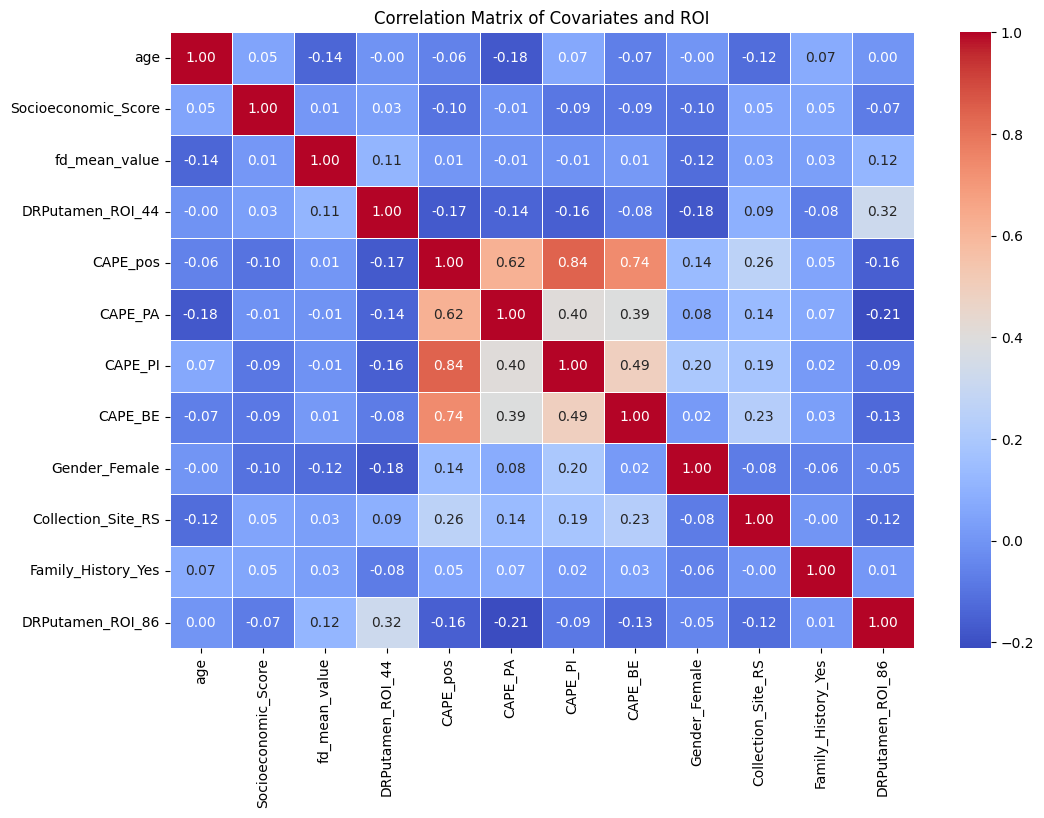

In [6]:
# Compute and visualize correlations between covariates
import matplotlib.pyplot as plt
import seaborn as sns

# Use the same fixed-effects structure as your mixed model
variables = ['age', 'gender', 'abepscore', 'colection_site', 'fd_mean_value', 'selection', 'roi_44']
model_data = tmap_allsubj_organized['DRPutamen'][variables + ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']].copy()

# One-hot encode categorical variables for correlation matrix and VIF diagnostics
model_data_encoded = pd.get_dummies(
    model_data,
    columns=['gender', 'colection_site', 'selection'],
    drop_first=True
)

# Make sure the target variables are present and the ROI variable is numeric
model_data_encoded['roi_44'] = tmap_allsubj_organized['DRPutamen']['roi_44']
model_data_encoded['roi_86'] = tmap_allsubj_organized['DRPutamen']['roi_86']

#rename columns for clarity
model_data_encoded.rename(columns={
    'cape_tot': 'CAPE_pos',
    'cape_PA_score': 'CAPE_PA',
    'cape_PI_score': 'CAPE_PI',
    'cape_BE_score': 'CAPE_BE',
    'roi_44': 'DRPutamen_ROI_44',
    'roi_86': 'DRPutamen_ROI_86',
    'selection_2': 'Family_History_Yes',
    'abepscore': 'Socioeconomic_Score',
    'gender_2': 'Gender_Female',
    'colection_site_2.0': 'Collection_Site_RS',
}, inplace=True)

corr_matrix = model_data_encoded.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Covariates and ROI')
plt.show()

In [ ]:
"""
Diagnostic suite for statsmodels OLS models.

Adaptado de mixedlm_diagnostics.py: mantém as mesmas checagens, exceto as
que são específicas de modelos mistos (normalidade dos efeitos aleatórios,
ICC, variância de grupo, LRT mixed vs OLS). O leave-one-group-out, quando
solicitado, agora reajusta via smf.ols em vez de smf.mixedlm.

Usage:
    from ols_diagnostics import run_diagnostics_ols

    results = run_diagnostics_ols(
        model,
        data=tmap_allsubj_organized[seed],
        outcome_col=cape,
        fixed_formula="cape ~ roi_X + age + C(gender) + abepscore + fd_mean_value + C(selection)",
        continuous_predictors=["age", "abepscore", "fd_mean_value"],
        categorical_predictors=["gender", "selection"],
        group_col="colection_site",   # opcional, só para inspeção visual
    )

Assumes `model` is a fitted result object from:
    smf.ols(formula, data=...).fit()
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor


def run_diagnostics_ols(model, data, outcome_col, fixed_formula=None,
                         continuous_predictors=None, categorical_predictors=None,
                         group_col=None, save_prefix=None):
    """
    model: fitted OLSResults (de smf.ols(formula, data=...).fit())
    data: dataframe usado para ajustar o modelo (mesmas linhas, sem NaN nas
          variáveis do modelo)
    outcome_col: nome da variável de desfecho
    fixed_formula: fórmula usada para ajustar `model` (necessária apenas se
                   group_col for passado, para o refit leave-one-group-out)
    continuous_predictors: lista de preditores contínuos para checagem de
                            linearidade
    categorical_predictors: lista de preditores categóricos para checagem de
                             resíduos por grupo
    group_col: opcional. Nome de uma coluna de cluster/site (ex.: site de
               coleta). Se fornecida, gera um boxplot exploratório de
               resíduos por grupo, apenas como inspeção visual de possível
               dependência -- SEM ICC e SEM LRT, pois esses são conceitos
               específicos de modelos mistos e não se aplicam a OLS.
    save_prefix: se fornecido, salva cada figura como
                 f"{save_prefix}_<name>.png" em vez de exibir na tela.
    """
    resid = model.resid
    fitted = model.fittedvalues
    out = {}

    def _save_or_show(fig, name):
        if save_prefix:
            fig.savefig(f"{save_prefix}_{name}.png", dpi=150, bbox_inches="tight")
            plt.close(fig)
        else:
            plt.show()

    # ---------- 1. Linearidade ----------
    if continuous_predictors:
        n = len(continuous_predictors)
        fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
        axes = np.atleast_1d(axes)
        for ax, var in zip(axes, continuous_predictors):
            ax.scatter(data[var], resid, alpha=0.4, s=15)
            ax.axhline(0, color="red", linestyle="--")
            ax.set_xlabel(var)
            ax.set_ylabel("Residuals")
            ax.set_title(f"Residuals vs {var}")
        fig.tight_layout()
        _save_or_show(fig, "linearity")

    # ---------- 2. Normalidade dos resíduos ----------
    fig, ax = plt.subplots(figsize=(5, 5))
    stats.probplot(resid, dist="norm", plot=ax)
    ax.set_title("QQ plot: residuals")
    _save_or_show(fig, "qq_residuals")
    sw_stat, sw_p = stats.shapiro(resid) if len(resid) <= 5000 else (np.nan, np.nan)
    out["shapiro_residuals"] = {"stat": sw_stat, "p": sw_p}

    # ---------- 3. Homocedasticidade ----------
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(fitted, resid, alpha=0.4, s=15)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("Residuals")
    ax.set_title("Residuals vs Fitted")
    _save_or_show(fig, "resid_vs_fitted")

    X_bp = sm.add_constant(fitted)
    bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(resid, X_bp)
    out["breusch_pagan"] = {"lm_stat": bp_lm, "lm_p": bp_lm_p, "f_stat": bp_f, "f_p": bp_f_p}

    if categorical_predictors:
        for var in categorical_predictors:
            fig, ax = plt.subplots(figsize=(6, 4))
            data.assign(_resid=resid).boxplot(column="_resid", by=var, ax=ax)
            ax.set_title(f"Residuals by {var}")
            plt.suptitle("")
            _save_or_show(fig, f"resid_by_{var}")

    # ---------- 4. Independência (checagem exploratória, sem ICC/LRT) ----------
    if group_col:
        fig, ax = plt.subplots(figsize=(7, 4))
        data.assign(_resid=resid).boxplot(column="_resid", by=group_col, ax=ax)
        ax.set_title(f"Residuals by {group_col} (visual check only, no ICC in OLS)")
        plt.suptitle("")
        plt.xticks(rotation=45)
        _save_or_show(fig, "resid_by_group")

    # Durbin-Watson: checa autocorrelação dos resíduos (relevante em OLS,
    # sem equivalente direto na suíte de mixedlm)
    out["durbin_watson"] = durbin_watson(resid)

    # ---------- 5. Outliers / influência ----------
    std_resid = resid / resid.std()
    flagged = data.index[np.abs(std_resid) > 3]
    out["outliers_std_resid_gt3"] = list(flagged)

    # Cook's distance: diagnóstico de influência padrão para OLS, disponível
    # diretamente via get_influence() (não existe equivalente simples em MixedLM)
    influence = model.get_influence()
    cooks_d, cooks_p = influence.cooks_distance
    cooks_threshold = 4 / len(data)
    out["cooks_distance_flagged"] = list(data.index[cooks_d > cooks_threshold])

    # leave-one-group-out refit stability (agora via smf.ols)
    if fixed_formula and group_col:
        groups_unique = data[group_col].unique()
        coef_shifts = {}
        base_params = model.params
        for g in groups_unique:
            sub = data[data[group_col] != g]
            try:
                m_sub = smf.ols(fixed_formula, data=sub).fit()
                shift = (m_sub.params - base_params).abs()
                coef_shifts[g] = shift.to_dict()
            except Exception as e:
                coef_shifts[g] = {"error": str(e)}
        out["leave_one_group_out_shifts"] = coef_shifts

    # ---------- 6. Multicolinearidade ----------
    X = model.model.exog
    exog_names = model.model.exog_names
    vif_vals = {}
    for i, name in enumerate(exog_names):
        try:
            vif_vals[name] = variance_inflation_factor(X, i)
        except Exception:
            vif_vals[name] = np.nan
    out["vif"] = vif_vals

    return out


def print_summary(results):
    """Pretty-print the key numbers from run_diagnostics_ols output."""
    print("=== Normality ===")
    print(f"Shapiro-Wilk (residuals): stat={results['shapiro_residuals']['stat']:.4f}, "
          f"p={results['shapiro_residuals']['p']:.4f}")

    print("\n=== Homoscedasticity ===")
    bp = results["breusch_pagan"]
    print(f"Breusch-Pagan: LM stat={bp['lm_stat']:.4f}, p={bp['lm_p']:.4f}")

    if "durbin_watson" in results:
        print("\n=== Autocorrelation ===")
        print(f"Durbin-Watson: {results['durbin_watson']:.4f} (~2 = sem autocorrelação)")

    print("\n=== Outliers / Influence ===")
    print(f"Observations with |std resid| > 3: {len(results['outliers_std_resid_gt3'])}")
    print(results["outliers_std_resid_gt3"])
    if "cooks_distance_flagged" in results:
        print(f"Observations flagged by Cook's distance (> 4/n): {len(results['cooks_distance_flagged'])}")
        print(results["cooks_distance_flagged"])

    print("\n=== Multicollinearity (VIF) ===")
    for name, v in results["vif"].items():
        flag = "  <-- high" if isinstance(v, float) and v > 5 else ""
        print(f"{name}: {v:.2f}{flag}" if isinstance(v, float) else f"{name}: {v}")

----Diagnostics for cape_tot with ROI 44 completed and saved to D://second_level_results.---
----Equation: cape_tot ~ roi_44 + age + C(gender) + abepscore + fd_mean_value + C(selection)---
beta=-0.887, p-value=0.000
=== Normality ===
Shapiro-Wilk (residuals): stat=0.9080, p=0.0000
n groups (for random-effect QQ): 2

=== Homoscedasticity ===
Breusch-Pagan: LM stat=11.5596, p=0.0007

=== Independence / clustering ===
ICC (group variance share): 0.1552
Group variance: 4.2338, Residual variance: 23.0536
LRT vs OLS (random intercept): stat=34.2041, p(boundary-corrected)=0.0000

=== Outliers ===
Observations with |std resid| > 3: 8
[43, 59, 73, 122, 202, 231, 386, 404]

=== Multicollinearity (VIF) ===
Intercept: 15.21  <-- high
C(gender)[T.2]: 1.06
C(selection)[T.2]: 1.02
roi_44: 1.05
age: 1.03
abepscore: 1.02
fd_mean_value: 1.05
----Diagnostics for cape_tot with ROI 44 completed and saved to D://second_level_results.---
----Equation: cape_tot ~ roi_44 + age + C(gender) + abepscore + fd_mean

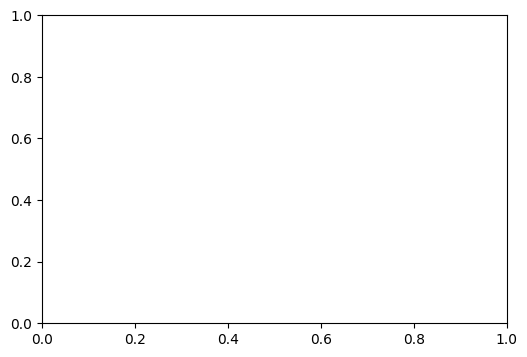

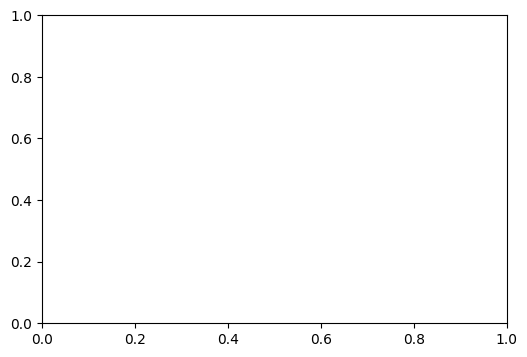

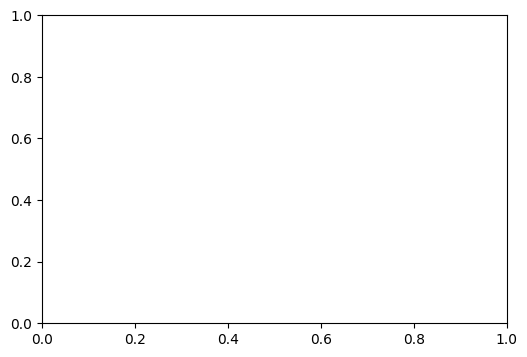

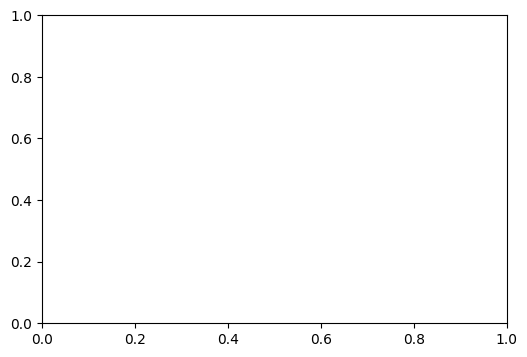

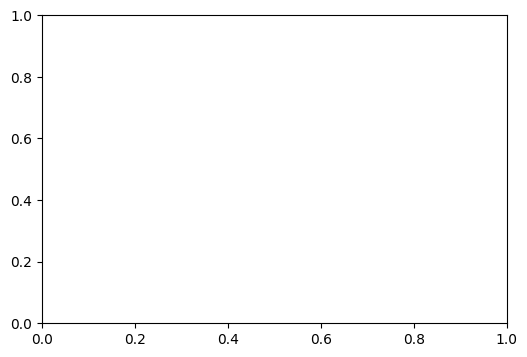

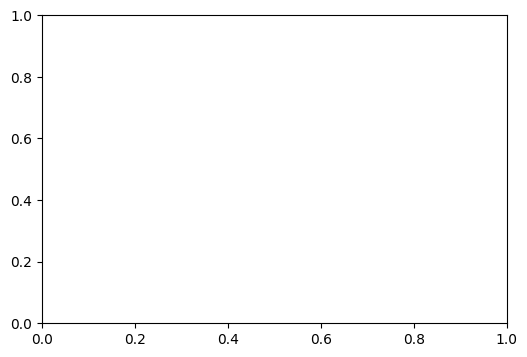

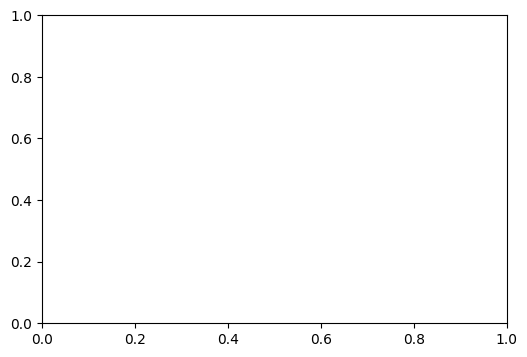

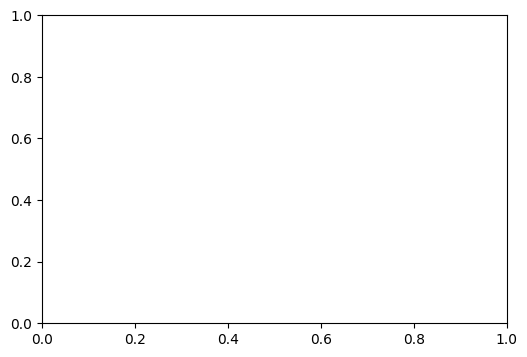

In [ ]:
for cape, roi in zip(['cape_tot', 'cape_PA_score'], [44, 86]):
        for equation in [f'{cape} ~ roi_{roi} + age + C(gender) + abepscore + fd_mean_value + C(selection) + C(colection_site)',
                        f'{cape} ~ roi_{roi} + age + C(gender) + abepscore + fd_mean_value + C(colection_site)',
                        f'{cape} ~ roi_{roi} + age + C(gender) + fd_mean_value + C(colection_site)',
                        f'{cape} ~ roi_{roi} + age + C(gender) + fd_mean_value + C(selection) + C(colection_site)']:
                model = smf.ols(equation, 
                    data=tmap_allsubj_organized['DRPutamen'])
                fit = model.fit()

                print(f"----Diagnostics for {cape} with ROI {roi} completed and saved to {output}.---")
                print(f"----Equation: {equation}---")
                print(f'beta={fit.params[f"roi_{roi}"]:.3f}, p-value={fit.pvalues[f"roi_{roi}"]:.3f}')
                
                print_summary(run_diagnostics_ols(
                        model=fit,
                        data=tmap_allsubj_organized['DRPutamen'],
                        # group_col="colection_site",
                        outcome_col=f'{cape}',
                        fixed_formula=equation,
                        continuous_predictors=[f'roi_{roi}', 'age', 'abepscore', 'fd_mean_value'],
                        categorical_predictors=['gender', 'selection', 'colection_site'],
                        save_prefix=os.path.join(output, f'diagnostics_DRPutamen_{cape}')
        ))

In [ ]:
"""
Bootstrap por indivíduo (case/cluster bootstrap) para avaliar a robustez da
inferência (IC e significância) de modelos OLS frente à heterocedasticidade,
conforme solicitado para os dois achados significativos pós-FDR:
  - ROI 44  x CAPE-pos
  - ROI 86  x CAPE-PA

Racional:
  A heterocedasticidade não enviesa o coeficiente pontual do modelo, mas pode
  invalidar os erros-padrão (e portanto p-valor/IC) estimados sob o pressuposto
  de variância constante. O bootstrap por cluster (reamostrando sujeitos
  inteiros, preservando suas medidas repetidas) fornece uma estimativa da
  distribuição amostral do coeficiente que não depende desse pressuposto,
  servindo como checagem de robustez -- e não como um novo teste a ser incluído
  na correção de múltiplas comparações original (que já foi aplicada aos 294
  modelos no screening primário).

Diferenças em relação à versão MixedLM (cluster_bootstrap_mixedlm.py):
  - Ajusta smf.ols(...).fit() em vez de smf.mixedlm(...).fit() -- não há
    re_formula nem optimizer_kwargs (reml/lbfgs), pois esses conceitos não
    existem em OLS.
  - Não existe "convergência" no sentido do MixedLM; o ajuste OLS falha
    apenas por problemas numéricos (ex.: matriz de desenho singular em uma
    réplica, o que pode acontecer se um cluster reamostrado não cobrir todos
    os níveis de uma variável categórica). Esses casos são capturados e
    contados em n_failed, do mesmo jeito que antes.
  - group_col aqui deve ser o identificador de sujeito (ex.: 'sub_id'), não o
    site -- o cluster bootstrap sempre reamostra por sujeito; stratify_col
    é o que controla a preservação do N por site.

Uso típico:
  from cluster_bootstrap_ols import cluster_bootstrap_ols, summarize_bootstrap

  res = cluster_bootstrap_ols(
      data=df,
      formula="cape_pos ~ roi44_fc + fd_mean_value + idade + sexo + C(site)",
      group_col="sub_id",
      coef_name="roi44_fc",
      n_boot=2000,
      stratify_col="site",  # recomendado p/ coorte multissítio: preserva N por site
      seed=42,
  )
  summarize_bootstrap(res, original_coef=..., original_p=...)
"""

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from typing import Optional
from tqdm import tqdm


def cluster_bootstrap_ols(
    data: pd.DataFrame,
    formula: str,
    group_col: str,
    coef_name: str,
    n_boot: int = 2000,
    stratify_col: Optional[str] = None,
    seed: int = 42,
):
    """
    Case (cluster) bootstrap para OLS: reamostra sujeitos com reposição,
    mantendo todas as observações de cada sujeito reamostrado juntas.

    Parameters
    ----------
    stratify_col : reamostra separadamente dentro de cada nível dessa coluna
        (ex.: 'site'), preservando o N original por site -- recomendado para
        coortes multissítio como a BHRCS, para não inflar/desbalancear sites
        aleatoriamente entre réplicas.
    """
    rng = np.random.default_rng(seed)

    boot_coefs = []
    n_failed = 0

    for b in tqdm(range(n_boot), desc=f"Bootstrap [{coef_name}]"):
        pieces = []

        if stratify_col is not None:
            strata = data[stratify_col].unique()
            for stratum in strata:
                stratum_df = data[data[stratify_col] == stratum]
                subj_in_stratum = stratum_df[group_col].unique()
                sampled = rng.choice(subj_in_stratum, size=len(subj_in_stratum), replace=True)
                for i, s in enumerate(sampled):
                    sub_df = stratum_df[stratum_df[group_col] == s].copy()
                    sub_df[group_col] = f"{s}_{stratum}_{i}"
                    pieces.append(sub_df)
        else:
            subjects = data[group_col].unique()
            sampled = rng.choice(subjects, size=len(subjects), replace=True)
            for i, s in enumerate(sampled):
                sub_df = data[data[group_col] == s].copy()
                sub_df[group_col] = f"{s}_{i}"
                pieces.append(sub_df)

        boot_df = pd.concat(pieces, ignore_index=True)

        try:
            result = smf.ols(formula, data=boot_df).fit()
            boot_coefs.append(result.params[coef_name])
        except Exception:
            n_failed += 1
            continue

    boot_coefs = np.array(boot_coefs)
    return {
        "coef_name": coef_name,
        "boot_coefs": boot_coefs,
        "n_boot_requested": n_boot,
        "n_converged": len(boot_coefs),
        "n_failed": n_failed,
        "pct_converged": 100 * len(boot_coefs) / n_boot,
    }


def summarize_bootstrap(res: dict, original_coef: float, original_p: Optional[float] = None, alpha: float = 0.05):
    """
    Resume o resultado do bootstrap: IC percentílico e um p-valor aproximado
    por método percentílico simples.
    """
    boot_coefs = res["boot_coefs"]
    lower_pct = 100 * (alpha / 2)
    upper_pct = 100 * (1 - alpha / 2)
    ci_lower, ci_upper = np.percentile(boot_coefs, [lower_pct, upper_pct])

    # p-valor aproximado (método percentílico simples) -- reportar com ressalva
    # de que é uma aproximação, não um teste formal sob H0.
    p_boot_approx = 2 * min((boot_coefs > 0).mean(), (boot_coefs < 0).mean())
    p_boot_approx = min(p_boot_approx, 1.0)

    excludes_zero = (ci_lower > 0) or (ci_upper < 0)

    print(f"--- Bootstrap por indivíduo: {res['coef_name']} ---")
    print(f"Réplicas ajustadas com sucesso: {res['n_converged']}/{res['n_boot_requested']} ({res['pct_converged']:.1f}%)")
    print(f"Coeficiente original: {original_coef:.4f}")
    if original_p is not None:
        print(f"p-valor original (após BH-FDR): {original_p:.4g}")
    print(f"Coeficiente médio bootstrap: {boot_coefs.mean():.4f} (SD={boot_coefs.std():.4f})")
    print(f"IC percentílico {100*(1-alpha):.0f}%: [{ci_lower:.4f}, {ci_upper:.4f}]")
    print(f"IC exclui zero: {excludes_zero}")
    print(f"p-valor bootstrap aproximado (percentílico): {p_boot_approx:.4g}")
    print("Nota: o p-valor bootstrap acima é uma aproximação baseada na distribuição")
    print("empírica em torno da estimativa observada, não um teste formal sob H0.")
    print("Para reporte, prefira descrever se o IC exclui zero e é consistente")
    print("com a direção/magnitude do achado original.")

    return {
        "ci_95": (ci_lower, ci_upper),
        "excludes_zero": excludes_zero,
        "p_boot_approx": p_boot_approx,
        "boot_mean": boot_coefs.mean(),
        "boot_sd": boot_coefs.std(),
    }


if __name__ == "__main__":
    print(__doc__)

    for cape, roi, original_coef, original_p in zip(
        ['cape_tot', 'cape_PA_score'], [44, 86], [-0.887, -0.249], [0.079, 0.01]
    ):
        res = cluster_bootstrap_ols(
            data=tmap_allsubj_organized['DRPutamen'],
            formula=f'{cape} ~ roi_{roi} + age + C(gender) + abepscore + fd_mean_value + C(selection) + C(colection_site)',
            group_col="sub_id",
            coef_name=f"roi_{roi}",
            n_boot=2000,
            stratify_col="colection_site",
            seed=42,
        )
        summarize_bootstrap(res, original_coef=original_coef, original_p=original_p)
    summarize_bootstrap(res, original_coef=original_coef, original_p=original_p)


Bootstrap por indivíduo (case/cluster bootstrap) para avaliar a robustez da
inferência (IC e significância) de modelos MixedLM frente à heterocedasticidade,
conforme solicitado para os dois achados significativos pós-FDR:
  - ROI 44  x CAPE-pos
  - ROI 86  x CAPE-PA

Racional:
  A heterocedasticidade não enviesa o coeficiente pontual do modelo, mas pode
  invalidar os erros-padrão (e portanto p-valor/IC) estimados sob o pressuposto
de variância constante. O bootstrap por cluster (reamostrando sujeitos
inteiros, preservando suas medidas repetidas) fornece uma estimativa da
distribuição amostral do coeficiente que não depende desse pressuposto,
servindo como checagem de robustez -- e não como um novo teste a ser incluído
na correção de múltiplas comparações original (que já foi aplicada aos 294
modelos no screening primário).

Uso típico:
  from cluster_bootstrap_mixedlm import cluster_bootstrap_mixedlm, summarize_bootstrap

  res = cluster_bootstrap_mixedlm(
      data=df,
      formul

Bootstrap [roi_44]: 100%|██████████| 2000/2000 [10:17<00:00,  3.24it/s]


--- Bootstrap por indivíduo: roi_44 ---
Réplicas convergidas: 2000/2000 (100.0%)
Coeficiente original: -0.8870
p-valor original (após BH-FDR): 0.079
Coeficiente médio bootstrap: -0.7682 (SD=0.2686)
IC percentílico 95%: [-1.2963, -0.2402]
IC exclui zero: True
p-valor bootstrap aproximado (percentílico): 0.003
Nota: o p-valor bootstrap acima é uma aproximação baseada na distribuição
empírica em torno da estimativa observada, não um teste formal sob H0.
Para reporte, prefira descrever se o IC exclui zero e é consistente
com a direção/magnitude do achado original.


Bootstrap [roi_86]: 100%|██████████| 2000/2000 [10:49<00:00,  3.08it/s]

--- Bootstrap por indivíduo: roi_86 ---
Réplicas convergidas: 2000/2000 (100.0%)
Coeficiente original: -0.2490
p-valor original (após BH-FDR): 0.01
Coeficiente médio bootstrap: -0.2625 (SD=0.0785)
IC percentílico 95%: [-0.4175, -0.1111]
IC exclui zero: True
p-valor bootstrap aproximado (percentílico): 0
Nota: o p-valor bootstrap acima é uma aproximação baseada na distribuição
empírica em torno da estimativa observada, não um teste formal sob H0.
Para reporte, prefira descrever se o IC exclui zero e é consistente
com a direção/magnitude do achado original.
